In [1]:
!git clone https://github.com/ajurcik/MLPrague-2026-test.git

Cloning into 'MLPrague-2026-test'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 168 (delta 67), reused 135 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 16.38 MiB | 23.23 MiB/s, done.
Resolving deltas: 100% (67/67), done.
Filtering content: 100% (7/7), 86.42 MiB | 23.17 MiB/s, done.


In [2]:
!pip install ./MLPrague-2026-test

Processing ./MLPrague-2026-test
  Preparing metadata (setup.py) ... done
  Created wheel for szn-advertising-research-ml-prague-2026: filename=szn_advertising_research_ml_prague_2026-0.0.1-py3-none-any.whl size=9111 sha256=82fd3de7176d9d400f5b9fd978ca2b85208ff4c7cdd09d0403df4733b4655cfb
  Stored in directory: /root/.cache/pip/wheels/d8/cb/42/cd041f010ad9bbdf861958c75fcaf86ce5f7d307ccef42e0f8
Successfully built szn-advertising-research-ml-prague-2026


# Introduction

In this notebook you will become familiar with the **YelpChi** dataset.
The dataset consists of real-world hotel and restaurant reviews, some of which have been marked as not recommended (i.e. spam) by Yelp.

We will perform:
* Explore the YelpChi dataset
* Review metrics that will be used for evaluation of a spam review detector
* Train a basic non-graph spam detector

In [3]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rich import print
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from ml_prague_2026.evaluation import compare_models, evaluate_model

In [4]:
YELP_CHI_PATH = "MLPrague-2026-test/data/yelpchi.parquet"

## 1. Dataset

About **YelpChi:**
* Collected from Yelp.com and first used by Mukherjee et al. [1]
* Originally included 67,395 reviews for a set of hotels and restaurants (201) in the Chicago area
* Filtered to 45,954 reviews by Dou et al. [2] for the purpose of graph anomally detection benchmarking
* Reviews include product and user information, timestamp, ratings, and a plaintext review
* Yelp has a filtering algorithm in place that identifies fake/suspicious reviews and separates them into a list of **not recommended** items - marked as **spam** in the data
* Our task is to isolate the spam reviews (i.e. anomalies) from the other benign/normal posts

[1] Mukherjee, Arjun, et al. ["Fake review detection: Classification and analysis of real and pseudo reviews."](https://www2.cs.uh.edu/~arjun/papers/UIC-CS-TR-yelp-spam.pdf) UIC-CS-03-2013. Technical Report. 2013.  
[2] Dou, Yingtong, et al. ["Enhancing graph neural network-based fraud detectors against camouflaged fraudsters."](https://arxiv.org/pdf/2008.08692) Proceedings of the 29th ACM international conference on information & knowledge management. 2020.

### Example - Product reviews

![yelp-chi-reviews.png](https://github.com/ajurcik/MLPrague-2026-test/blob/master/presentation/images/yelp-chi-reviews.png?raw=1)

### Example - Not recommended reviews

![yelp-chi-not-recommended.png](https://github.com/ajurcik/MLPrague-2026-test/blob/master/presentation/images/yelp-chi-not-recommended.png?raw=1)

### Data

In [5]:
yelp_chi = pd.read_parquet(YELP_CHI_PATH)

In [6]:
yelp_chi.columns

Index(['date', 'review_id', 'user_id', 'product_id', 'spam', 'useful', 'funny',
       'cool', 'stars', 'review', 'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5',
       'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14',
       'f_15', 'f_16', 'f_17', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25',
       'f_26', 'f_27', 'f_28', 'f_29', 'f_30', 'f_31', 'review_idx'],
      dtype='object')

In [7]:
FEATURES = [c for c in yelp_chi.columns if "f_" in c]

In [8]:
yelp_chi[[c for c in yelp_chi.columns if c not in FEATURES]].head(3)

,date,review_id,user_id,product_id,spam,useful,funny,cool,stars,review,review_idx
0,2011-06-08,MyNjnxzZVTPq,IFTr6_6NI4CgCVavIL9k5g,tQfLGoolUMu2J0igcWcoZg,0,28,11,18,5,Let me begin by saying that there are two kind...,0
1,2011-08-30,BdD7fsPqHQL73hwENEDT-Q,c_-hF15XgNhlyy_TqzmdaA,tQfLGoolUMu2J0igcWcoZg,0,4,3,0,3,The only place inside the Loop that you can st...,1
2,2009-06-26,BfhqiyfC,CiwZ6S5ZizAFL5gypf8tLA,tQfLGoolUMu2J0igcWcoZg,0,23,14,12,5,I have walked by the Tokyo Hotel countless tim...,2


### Benign examples

We will employ the most reviewed product - ID = `ALwH81_sqskLmwfWS-_eeQ`

In [9]:
for i, r in enumerate(yelp_chi[(yelp_chi["product_id"] == "ALwH81_sqskLmwfWS-_eeQ") & (yelp_chi["spam"] == 0)]["review"].sample(n=3)):
    print(f"Example #{i + 1}:")
    print("[green]" + textwrap.fill(r, 80) + "[/green]\n\n")

Example #1:

Henri: Everyone raves about this place. I just don't get it; the food is
mediocre at best. The wait around peak times is insane and when you do sit,
you're ignored for a long time.There's many other better restaurants in the
vicinity, try something new. Nicole: Love the food and the price is reasonable;
however, the service is awful. I use to live close to this restaurant so would
pop in often but after continuously being ignored by the staff we decided to
stop going. Plus, the Pho is better at Pho 777 and the Thai restaurant, Thai
Avenue, (next door on Broadway) both have wonderful food at a good price and the
staff is GREAT.

Example #2:

My favorite Argyle eatery... I alternate between 47 (beef pho), 92 (chicken
curry - best broth ever), and whatever the numbers are for the seared duck w/egg
noodles and catfish congee. They recently expanded their already colossal menu,
and some prices have gone up. But they're still cheap for big, yummy bowls of
soup. And on the bright side of the menu change, I no longer have to order my
spring rolls with no pork - shrimp only now has it's own number (and letter,
actually), hooray! If you're in a hurry, ask for your check as soon as the food
comes. They won't bring it to you unless you ask for it, and good luck flagging
them down during peak hours when the line's out the door. Waitstaff have always
been pleasant over the years, even when busy.

Example #3:

Great food, if you're verrrrrry careful what you order. They have a liberal
interpretation of the word "beef" - you can't assume it's the usual parts of the
cow you eat. Stick to the pho - I prefer the chicken pho because it's good,
soothes the soul, and chicken looks like chicken - you can't be fooled. I went
off the grid once, and ended up with very beefy stock with parts of cow I'd
never seen before.  And you need to request cilantro, they won't give it to you
otherwise.

### Spam examples

We will employ the most reviewed product - ID = `ALwH81_sqskLmwfWS-_eeQ`

In [10]:
for i, r in enumerate(yelp_chi[(yelp_chi["product_id"] == "ALwH81_sqskLmwfWS-_eeQ") & (yelp_chi["spam"] == 1)]["review"].sample(n=3)):
    print(f"Example #{i + 1}:")
    print("[red]" + textwrap.fill(r, 80) + "[/red]\n\n")

Example #1:

great place ! love the food but, they have to remodel ..... it looks pretty old
but its still a really good resturaunt! i recommend tank noodles out of any
other pho place! but just remodel..... other than that LOVE ITTTT (:oh and there
are really nice workers ! very friendly

Example #2:

This is my favorite Pho restaurant in Chicago! And I LOOOOOVE Pho! Tank is
always super busy on the weekends so try to come during the week. Oh and be
ready to share a table and eat with strangers if you have a small party. What I
love the most about Tank is it's no fuss and FAST. I always get the #39 bowl of
Pho, a marinated pork sandwich, and either the fresh shrimp spring rolls or
fried shrimp egg rolls. This place is consistent and the broth always tastes the
same. (I hate when other Pho restaurants taste differently depending on what
time you get there). Tank isn't the cleanest of all restaurants, and sometimes
you'll even get a thumb in your soup, but we all joke that that's where the
flavor comes from. =) Bring your own beer and wear something casual because you
will smell afterwards, but enjoy!*Note - I think Tank is closed until January
6th (double check before you go!)

Example #3:

tu pac, dmx, lady gaga and viet music all within one sitting....i would
definitely consider this place a "viet fast food" jointnot the cleanest, not the
best service.dj needs help, whoever dj is seems quite a bit confused....

### Review statistics

### TASK 1.A: Spam reviews

What is the ratio of spam reviews?

Run the following cell.

In [11]:
yelp_chi["spam"].value_counts() / len(yelp_chi)

,count
spam,
0,0.854703
1,0.145297


### User behaviour

### TASK 1.B: User count

What is the number of users?

Run the following cell.

In [12]:
yelp_chi["user_id"].nunique()

29431

### TASK 1.C: Spam users

What is the ratio of users producing spam reviews?

Mark users who produced at least 1 spam review using a new column `user_spam`.

In [13]:
# TASK 1.C: Spam users
# - mark users who produced at least one spam review using a new column "user_spam"
#
# - Hint: You can `groupby` by "user_id" and `transform` the "spam" column using the "any" function

yelp_chi["user_spam"] = yelp_chi.groupby("user_id")["spam"].transform("any")

yelp_chi.drop_duplicates("user_id")["user_spam"].value_counts() / yelp_chi["user_id"].nunique()

,count
user_spam,
False,0.794842
True,0.205158


<!-- #region -->
<details>
<summary><b>Task 1.C — Solution</b></summary>

```python
yelp_chi["user_spam"] = yelp_chi.groupby("user_id")["spam"].transform("any")
```

</details>
<!-- #endregion -->

### TASK 1.D: Spam users review count

Do behaviour of spam users differ from normal users? Consider review count.

Run the following cell.

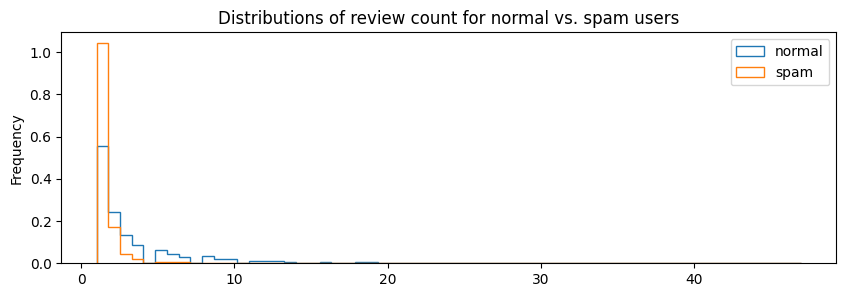

In [14]:
def compare_feature(df, feature, user_spam_col="user_spam", figsize=(10, 3)):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    bin_edges = np.histogram_bin_edges(yelp_chi[feature], 60)

    yelp_chi[yelp_chi[user_spam_col] == False][feature].plot.hist(bins=bin_edges, density=True, histtype="step", ax=ax)
    yelp_chi[yelp_chi[user_spam_col] == True][feature].plot.hist(bins=bin_edges, density=True, histtype="step", ax=ax)

    plt.title(f"Distributions of {" ".join(feature.split("_")[1:])} for normal vs. spam users")
    plt.legend(["normal", "spam"])
    plt.show()


yelp_chi["user_review_count"] = yelp_chi.groupby("user_id").transform("size")

compare_feature(yelp_chi, "user_review_count")

### TASK 1.E: Spam users activity span

Do behaviour of spam users differ from normal users? Consider activity span.

Run the following cell.

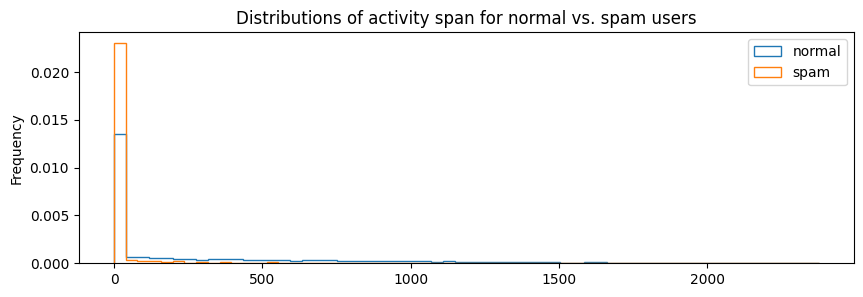

In [15]:
yelp_chi["user_activity_span"] = yelp_chi.groupby("user_id")["date"].transform(lambda x: x.max() - x.min()).dt.days

compare_feature(yelp_chi, "user_activity_span")

### Features

The dataset already provides hand-crafted features of the reviews. The features were obtained by extracting text features for reviews and combining them with behavioural features of the following entities:
1. Review - `f[0:15]`
2. User - `f[15:24]`
3. Product (hotel/restaurant) - `f[24:32]`

For more details, please refer to the work done by Rayana et al. [1].

[1] Rayana, Shebuti, and Leman Akoglu. ["Collective opinion spam detection: Bridging review networks and metadata."](https://shebuti.com/wp-content/uploads/2016/06/15-kdd-collectiveopinionspam.pdf) Proceedings of the 21th ACM SIGKDD international conference on knowledge discovery and data mining. 2015.

### TASK 1.F: Review node features

The feature `f_15` is the maximum number of reviews (MNR) posted by a user in a day.
**Warning**, the feature was normalized to `[0, 1]` in a non-linear way and 0 means the most extreme MNR value.  
What is the ratio of reviews written by users with high MNR?

Run the following cell.

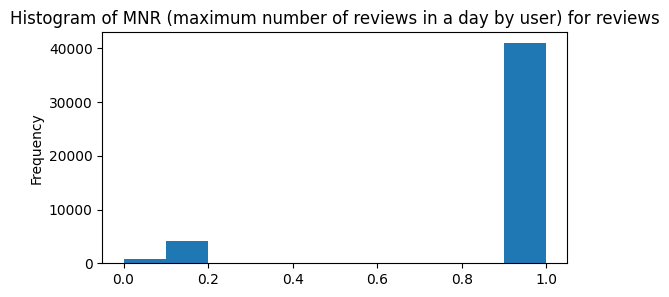

In [16]:
yelp_chi["f_15"].plot.hist(bins=10, title="Histogram of MNR (maximum number of reviews in a day by user) for reviews", figsize=(6, 3));

## 2. Anomaly detection

**Classification** metrics:
* *precision* - the accuracy of positive predictions
* *recall* - the ability to find all actual positives
* easy to interpret
* we compute macro average of metrics for normal and spam users

**Ranking** metrics:
* AUPRC - area under *precision-recall* curve, computed as [*average precision*](https://en.wikipedia.org/wiki/Evaluation_measures_(information_retrieval)#Average_precision)
* Rec@K - *recall* at K, where K = number of anomalies
* enable to evaluate models while not assuming a specific class thresholds as opposed to the classification ones

### Train/test datasets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(yelp_chi[FEATURES], yelp_chi["spam"].to_numpy(), test_size=0.2, stratify=yelp_chi["spam"])

### Random baseline

### TASK 2.A: Train a baseline model

Train a dummy, i.e., random, classifier and review the metrics.

Run the following cell.

In [18]:
clf_base = DummyClassifier(strategy="stratified")
clf_base.fit(X_train, y_train)

metrics_base = evaluate_model(
    "baseline",
    y_test,
    clf_base.predict(X_test),
    clf_base.predict_proba(X_test)[:, 1]
)

,Precision,Recall,AUPRC,Rec@K
0,0.502,0.502,0.144,0.139


### Random forest classifier

### TASK 2.B: Train a baseline classifier

Train `RandomForestClassifier`model using the features `X_train` and the labels `y_train` and review the metrics.

In [19]:
# TASK 2.B: train a baseline classifier
# - init and train `RandomForestClassifier` model using `X_train` and `y_train`

### YOUR CODE HERE ###

clf_rf = RandomForestClassifier()
clf_rf.fit(X_train, y_train)

### YOUR CODE HERE ###

metrics_rf = evaluate_model(
    "random_forest",
    y_test,
    clf_rf.predict(X_test),
    clf_rf.predict_proba(X_test)[:, 1]
)

,Precision,Recall,AUPRC,Rec@K
0,0.877,0.642,0.639,0.578


<!-- #region -->
<details>
<summary><b>Task 2.B — Solution</b></summary>

```python
clf_rf = RandomForestClassifier()
clf_rf.fit(X_train, y_train)
```

</details>
<!-- #endregion -->

### TASK 2.C: Review metrics

Compare the baseline models using the choosen metrics.

Run the following cell.

,Precision,Recall,AUPRC,Rec@K
Model,,,,
baseline,0.502,0.502,0.144,0.139
random_forest,0.877,0.642,0.639,0.578


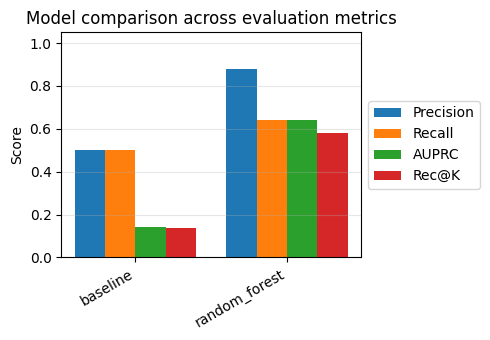

In [20]:
compare_models([metrics_base, metrics_rf])